# Analisi Esplorativa del Dataset (EDA) - Basket Action Recognition
Questo notebook contiene l'analisi esplorativa e dinamica del dataset di clip video. L'obiettivo è analizzare lo sbilanciamento delle classi, visualizzare le clip di anteprima, mappare le proprietà temporali (FPS/durata) e tracciare l'intensità di movimento intrinseca di ogni azione di gioco.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# 1. Impostazioni di visualizzazione standard dei grafici
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Definizione centralizzata dei percorsi relativi
DATASET_BASE_PATH = "../../data/datasets/dataset_basket_v1_original"
MANIFEST_PATH = os.path.join(DATASET_BASE_PATH, "manifest.csv")

# 3. Caricamento centralizzato del DataFrame manifest
if os.path.exists(MANIFEST_PATH):
    df = pd.read_csv(MANIFEST_PATH)
    print(f"Dataset caricato correttamente! Clip registrate: {len(df)}")
else:
    print(f"ERRORE: File manifest non trovato al percorso: {MANIFEST_PATH}")

print("Directory operativa corrente:", os.getcwd())

Dataset caricato correttamente! Clip registrate: 5721
Directory operativa corrente: /Users/sebastianocaliendo/Desktop/FVAB-Riconoscimento-azioni-basket/src/data_analysis


## 1. Analisi dello Sbilanciamento delle Classi
Fissiamo la distribuzione analitica e quantitativa delle etichette del dataset per valutare l'adozione di adeguate strategie di bilanciamento (es. *class weights* o *weighted random sampler*) in fase di training.

,Conteggio,Percentuale (%)
label,,
passaggio,2505,43.786051
non-gioco,1503,26.271631
idle,855,14.944940
tiroDaDue0,266,4.649537
tiroDaDue1,189,3.303618
tiroDaTre0,152,2.656878
tiroLibero1,111,1.940220
tiroLibero0,82,1.433316
tiroDaTre1,58,1.013809


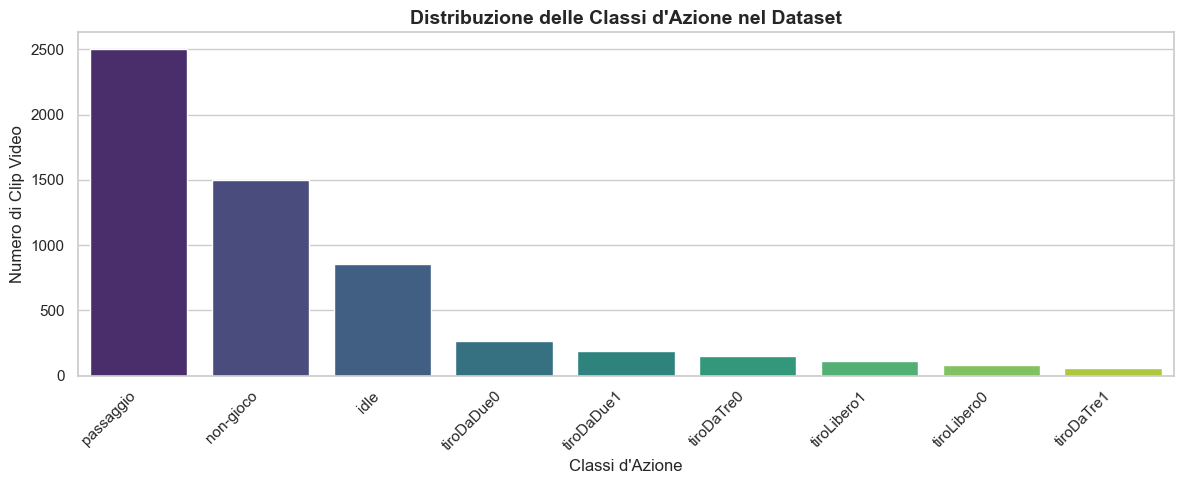

In [2]:
# Calcolo statistico delle frequenze
class_counts = df['label'].value_counts()
class_pcts = df['label'].value_counts(normalize=True) * 100

# Visualizzazione tabellare pulita dei dati
df_summary = pd.DataFrame({
    'Conteggio': class_counts,
    'Percentuale (%)': class_pcts
})
display(df_summary)

# Grafico a barre (Risolto il FutureWarning di Seaborn impostando hue)
plt.figure(figsize=(12, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='viridis', legend=False)
plt.title('Distribuzione delle Classi d\'Azione nel Dataset', fontsize=14, fontweight='bold')
plt.xlabel("Classi d'Azione", fontsize=12)
plt.ylabel('Numero di Clip Video', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Anteprima Visiva dei Frame (Controllo OpenCV)
Estraiamo un campione video casuale per ciascuna delle 9 classi d'azione per confermare visivamente l'integrità strutturale dei file video distribuiti sul disco.

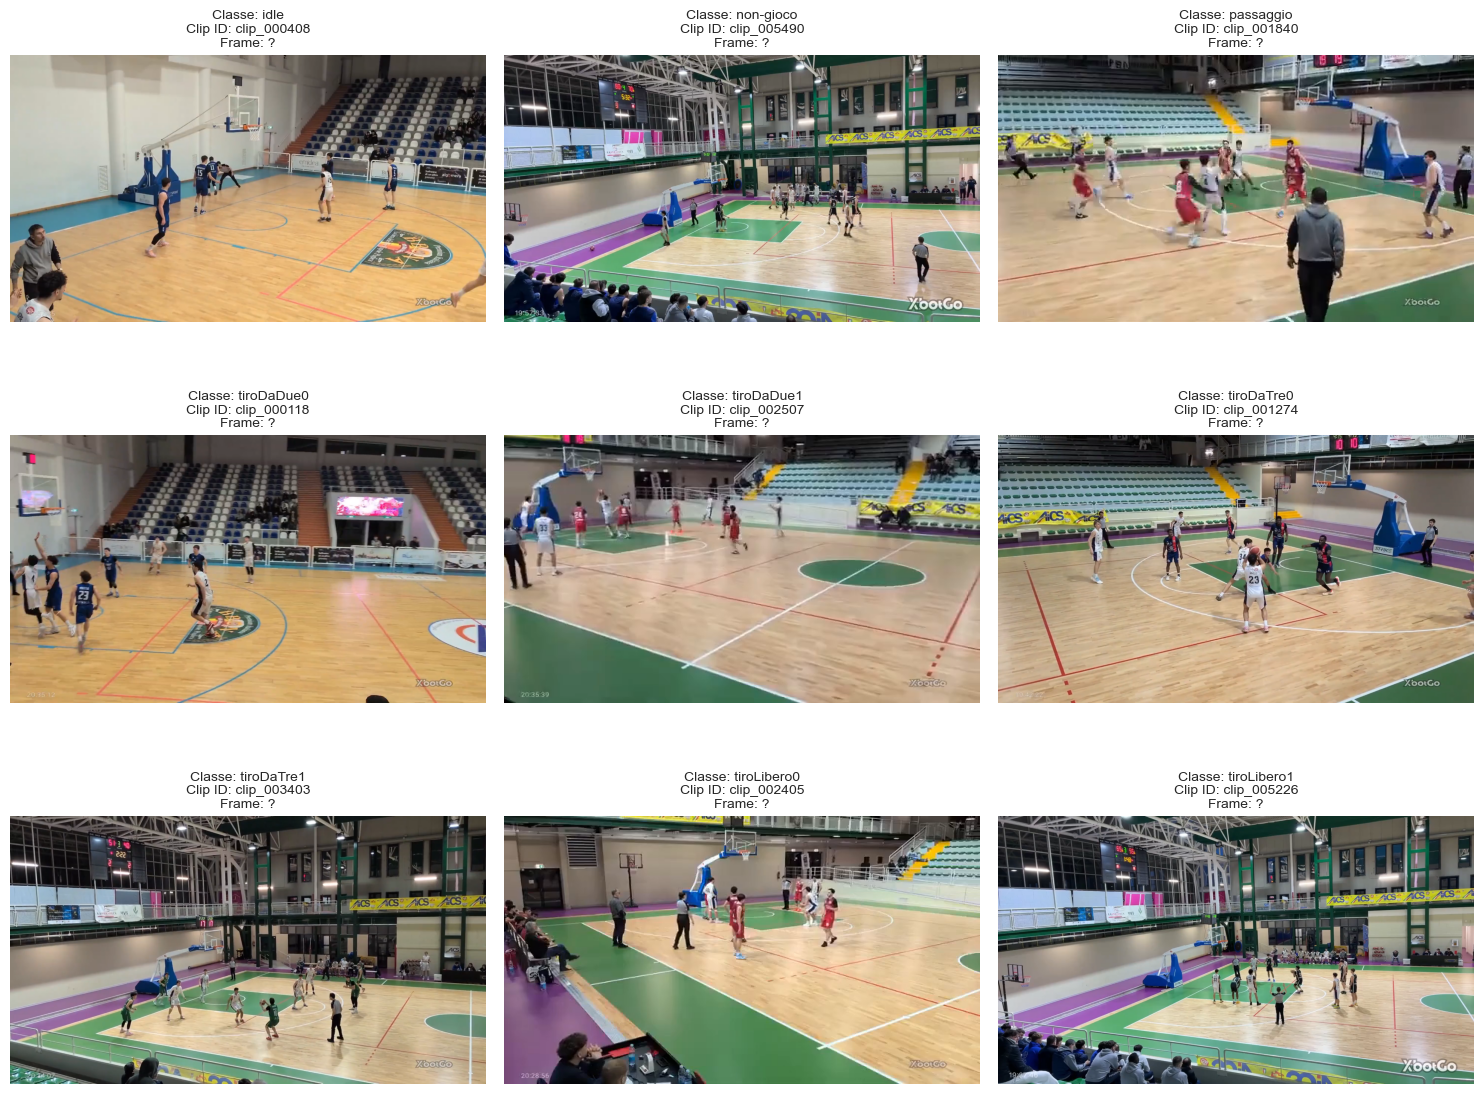

In [3]:
# Campionamento di un video per classe
df_sample = df.groupby('label').sample(n=1, random_state=42).reset_index(drop=True)

# Configurazione del plot multiriquadro 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, row in df_sample.iterrows():
    ax = axes[idx]
    path = os.path.join(DATASET_BASE_PATH, row['path'])
    
    cap = cv2.VideoCapture(path)
    if cap.isOpened():
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            ax.imshow(frame_rgb)
        cap.release()
    else:
        ax.text(0.5, 0.5, f'Video non trovato\n{path}', 
                 ha='center', va='center', transform=ax.transAxes, color='red', fontsize=10)
        ax.set_facecolor('#f0f0f0')
        
    ax.set_title(f"Classe: {row['label']}\nClip ID: {row['clip_id']}\nFrame: {row.get('total_frames', '?')}", fontsize=10)
    ax.axis('off')

for i in range(len(df_sample), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## 3. Analisi dei Frame Rate (FPS) e della Durata Temporale delle Clip
Questa sezione analizza le proprietà temporali intrinseche dei file video per calcolare la durata in secondi, controllando la presenza di framerate eterogenei che potrebbero compromettere l'apprendimento temporale dei modelli.

Estrazione metadati video in corso...


100%|██████████| 500/500 [00:05<00:00, 99.56it/s] 
/var/folders/qv/6h01n8hn0ts9lnx_7fdq337m0000gn/T/ipykernel_65087/778643155.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


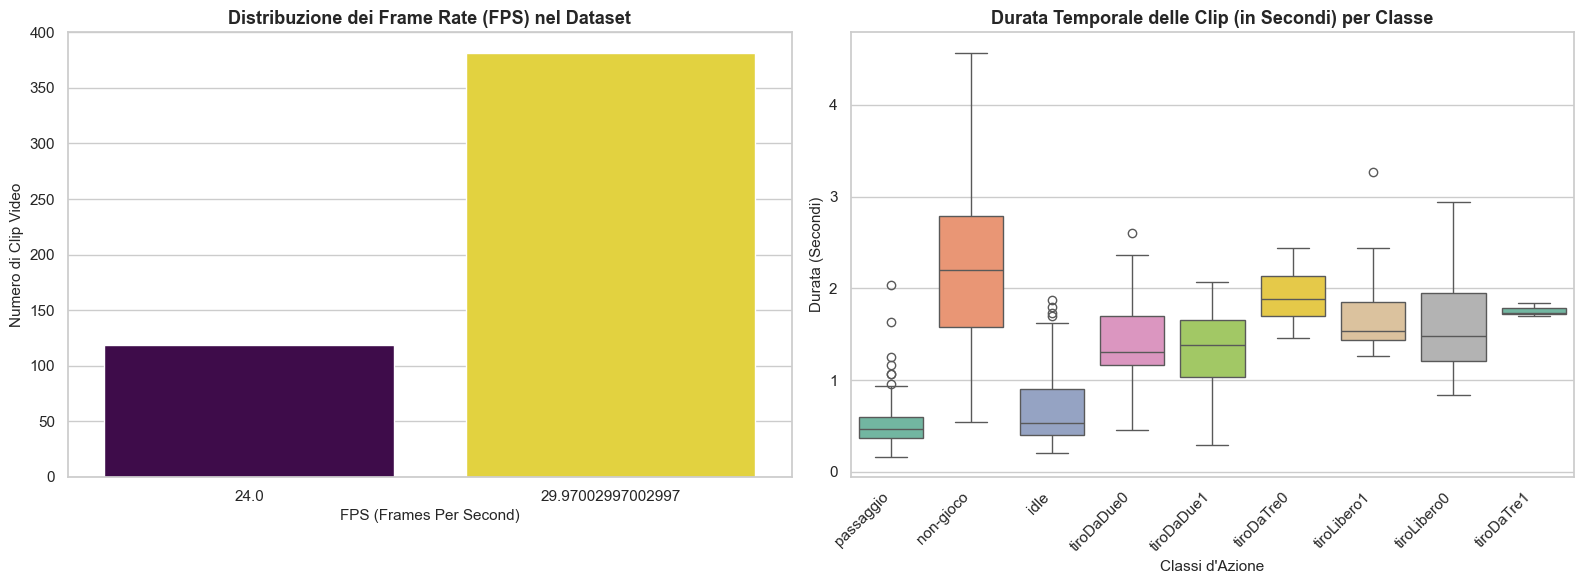


--- STATISTICHE DESCRITTIVE DELLA DURATA (Secondi) PER CLASSE ---


,mean,min,max
label,,,
idle,0.707200,0.200200,1.868533
non-gioco,2.199297,0.541667,4.571233
passaggio,0.506941,0.166667,2.041667
tiroDaDue0,1.377455,0.458333,2.602600
tiroDaDue1,1.347374,0.291667,2.068733
tiroDaTre0,1.923728,1.458333,2.435767
tiroDaTre1,1.757311,1.701700,1.835167
tiroLibero0,1.682317,0.833333,2.936267
tiroLibero1,1.791357,1.267933,3.269933


In [4]:
# Estrazione controllata su un campione significativo di 500 clip per efficienza computazionale
sample_size = min(500, len(df))
df_fps_analysis = df.sample(n=sample_size, random_state=42).copy()

fps_list, total_frames_list, duration_list = [], [], []

print(f"Estrazione metadati video in corso...")
for idx, row in tqdm(df_fps_analysis.iterrows(), total=len(df_fps_analysis)):
    path = os.path.join(DATASET_BASE_PATH, row['path'])
    cap = cv2.VideoCapture(path)
    
    if cap.isOpened():
        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
        duration = total_frames / fps if fps > 0 else 0
        
        fps_list.append(fps)
        total_frames_list.append(total_frames)
        duration_list.append(duration)
    else:
        fps_list.append(None)
        total_frames_list.append(None)
        duration_list.append(None)
    cap.release()

df_fps_analysis['fps'] = fps_list
df_fps_analysis['total_frames_extracted'] = total_frames_list
df_fps_analysis['duration_seconds'] = duration_list
df_fps_analysis = df_fps_analysis.dropna(subset=['fps'])

# Generazione dei grafici di distribuzione temporale
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico Distribuzione FPS
sns.countplot(data=df_fps_analysis, x='fps', ax=axes[0], hue='fps', palette='viridis', legend=False)
axes[0].set_title('Distribuzione dei Frame Rate (FPS) nel Dataset', fontsize=13, fontweight='bold')
axes[0].set_xlabel('FPS (Frames Per Second)', fontsize=11)
axes[0].set_ylabel('Numero di Clip Video', fontsize=11)

# Grafico Boxplot Durate
sns.boxplot(data=df_fps_analysis, x='label', y='duration_seconds', ax=axes[1], hue='label', palette='Set2', legend=False)
axes[1].set_title('Durata Temporale delle Clip (in Secondi) per Classe', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Classi d\'Azione', fontsize=11)
axes[1].set_ylabel('Durata (Secondi)', fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n--- STATISTICHE DESCRITTIVE DELLA DURATA (Secondi) PER CLASSE ---")
display(df_fps_analysis.groupby('label')['duration_seconds'].describe()[['mean', 'min', 'max']])

## 4. Analisi della Firma Dinamica (Profilo di Movimento)
Analizziamo la variazione pixel-by-pixel fra frame consecutivi ($|Frame_t - Frame_{t-1}|$). Questo ci permette di mappare l'andamento del movimento nel tempo per catturare visivamente le differenze dinamiche (es. la brevità esplosiva di un passaggio rispetto alla stasi delle fasi di *idle*).

Calcolo dell'intensità di movimento frame-by-frame...


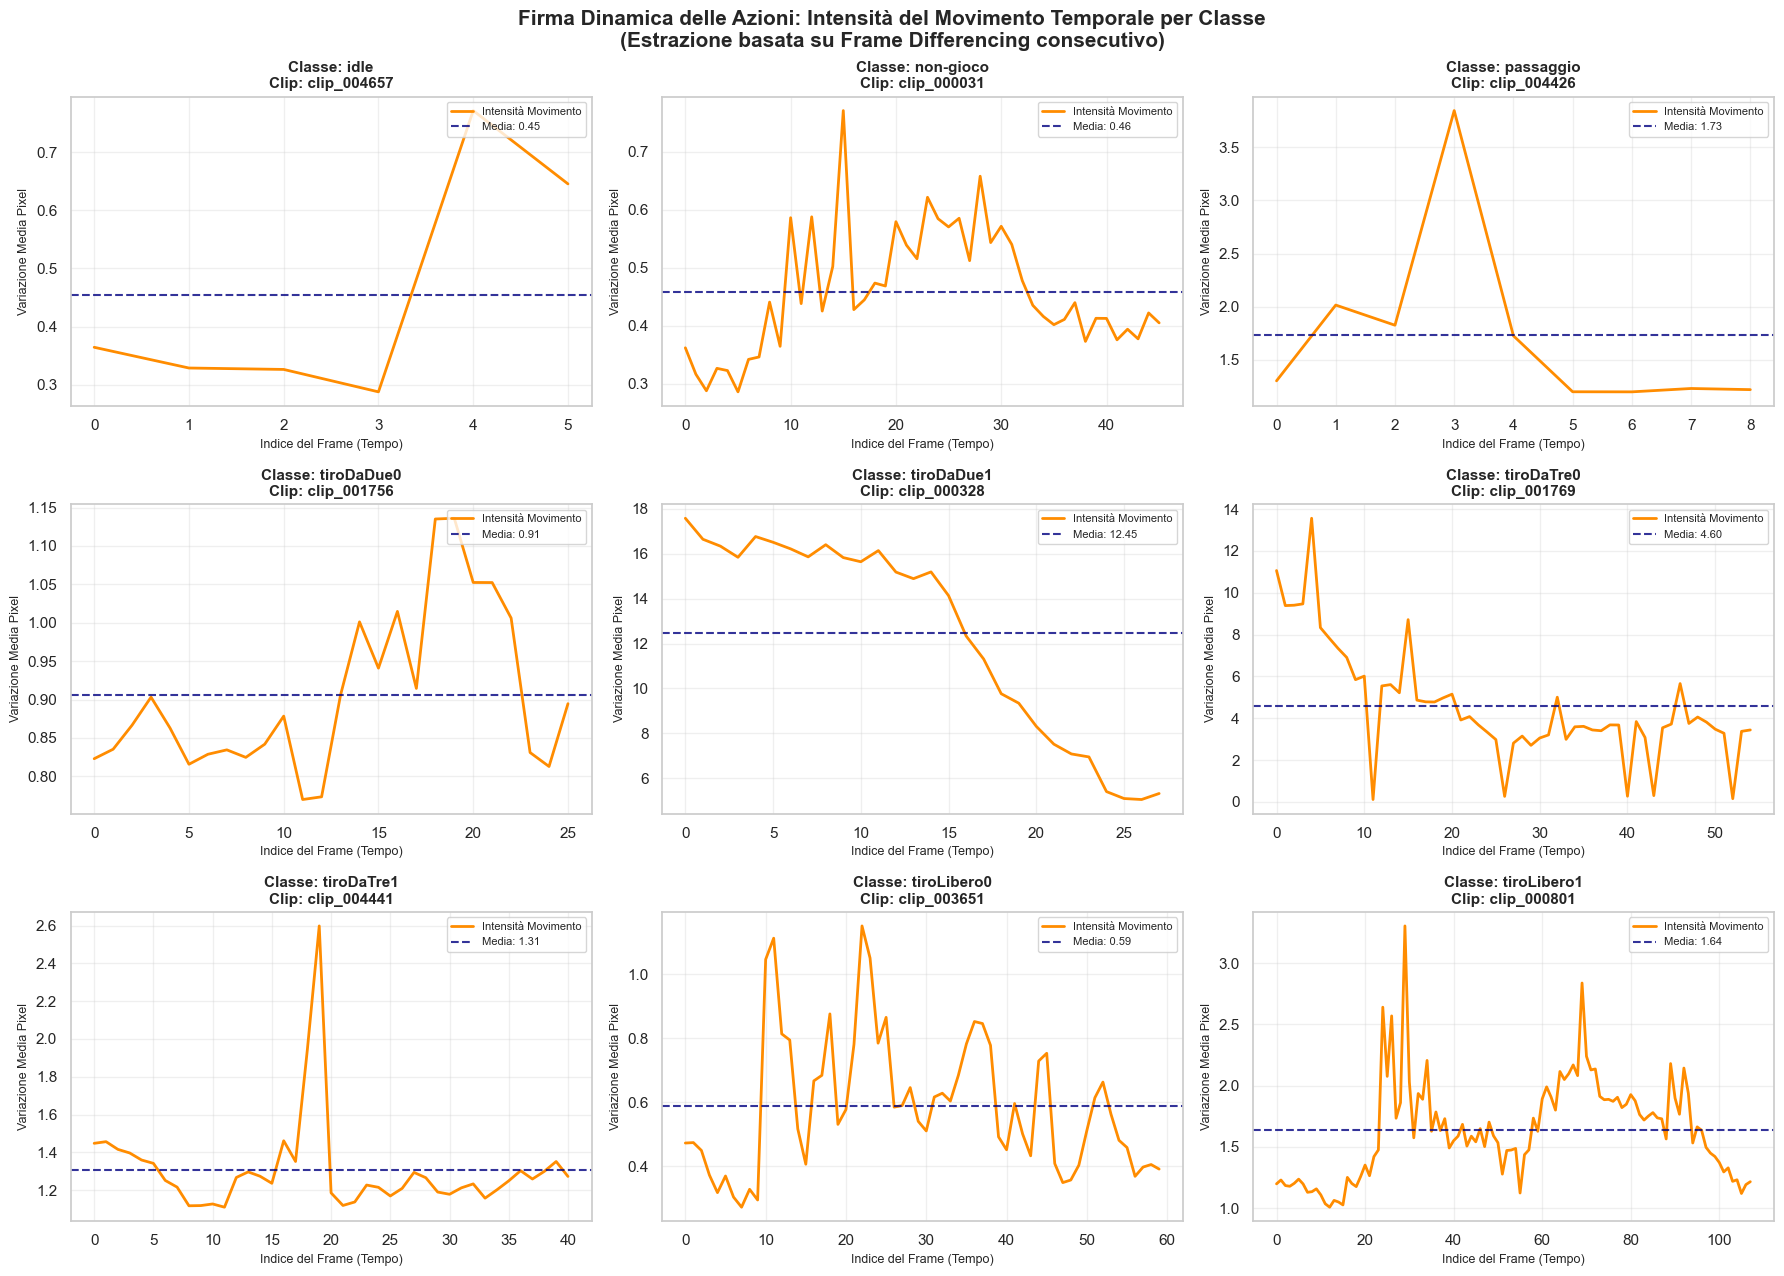

In [5]:
# Selezione di una clip per classe per analizzarne la firma dinamica temporale
df_motion_sample = df.groupby('label').sample(n=1, random_state=15).reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()

print("Calcolo dell'intensità di movimento frame-by-frame...")

for idx, row in df_motion_sample.iterrows():
    ax = axes[idx]
    path = os.path.join(DATASET_BASE_PATH, row['path'])
    
    cap = cv2.VideoCapture(path)
    motion_intensities = []
    
    ret, prev_frame = cap.read()
    if ret:
        prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            frame_diff = cv2.absdiff(gray, prev_gray)
            mean_motion = np.mean(frame_diff)
            
            motion_intensities.append(mean_motion)
            prev_gray = gray
    cap.release()
    
    if len(motion_intensities) > 0:
        ax.plot(motion_intensities, color='darkorange', linewidth=2, label='Intensità Movimento')
        avg_motion = np.mean(motion_intensities)
        ax.axhline(avg_motion, color='navy', linestyle='--', alpha=0.8, label=f'Media: {avg_motion:.2f}')
        ax.set_title(f"Classe: {row['label']}\nClip: {row['clip_id']}", fontsize=11, fontweight='bold')
        ax.set_xlabel("Indice del Frame (Tempo)", fontsize=9)
        ax.set_ylabel("Variazione Media Pixel", fontsize=9)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f"Video non caricabile\n{row['clip_id']}", ha='center', va='center', color='red')
        ax.set_facecolor('#f0f0f0')

for i in range(len(df_motion_sample), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Firma Dinamica delle Azioni: Intensità del Movimento Temporale per Classe\n(Estrazione basata su Frame Differencing consecutivo)", 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()